In [ ]:
import os, sys
import pandas as pd
from matplotlib import pyplot as plt
src = os.path.dirname(os.path.abspath("../src"))

if src not in sys.path:
    sys.path.append(src)

from src.amestools import DATA_DIR
from src.seqtools import Seqstat   
from src.evolution import Evolver

evolver = Evolver()
protein_seqstat = Seqstat(str(DATA_DIR / 'pfam80_stat.json'))

In [4]:
prior_dict = {"scopseq": [],
              "randseq": [],
              "scopscore": [],
              "rnadscore": [],
              "scopscore_norm": [],
              "rnadscore_norm": [],
              }

i = 0
for seq in protein_seqstat.read_fasta_generator('/data/saakyanh2/dbs/scop40.fa'):
    if any(c in seq for c in ['X', 'Z', 'B', 'J', 'O', 'U']):
                    continue
    seq_len = len(seq)
    rand_seq = evolver.randomseq('protein', seq_len)  
    prior_dict["scopseq"].append(seq)
    prior_dict["randseq"].append(rand_seq)
    prior_dict["scopscore"].append(protein_seqstat.n_gram_prior(seq))
    prior_dict["rnadscore"].append(protein_seqstat.n_gram_prior(rand_seq))
    prior_dict["scopscore_norm"].append(protein_seqstat.n_gram_prior(seq) / seq_len)
    prior_dict["rnadscore_norm"].append(protein_seqstat.n_gram_prior(rand_seq) / seq_len)
    i+=1
    print(i, end='\r')


df = pd.DataFrame(prior_dict)


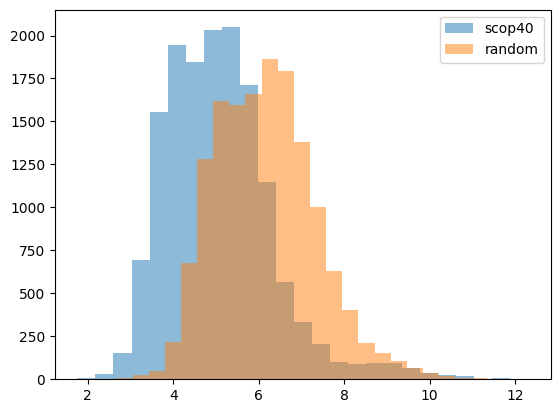

In [5]:
plt.hist(df.scopscore, bins=25, alpha = 0.5, label='scop40')
plt.hist(df.rnadscore, bins=25, alpha = 0.5, label='random')
plt.legend() 